# INFO-6147-(01)-26W Deep Learning with Pytorch

## Homework 5: GAN for RGB images

**Student Name:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 15th, 2026

**Description:**

1. Modify the DCGAN code to accept RGB images
2. Fix the normalization transformation to work with RGB images
3. Explain how the labels are different during training the Discriminator and the Generato

## Import Libs

In [2]:
import torch
from torch import nn
from tqdm.auto import tqdm
from torchvision import transforms,datasets
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

###  Check if CUDA is available and set PyTorch to use GPU or CPU

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Set Manual Seed

In [4]:
torch.manual_seed(42)

### Generate the method for showing the image
Transform the ganed tensor to RGB image and show

In [5]:
def show_tensor_images(image_tensor, num_images=25,size=(3, 64, 64)):
    # DeNormalized
    image_tensor = (image_tensor + 1) / 2
    # Move to CPU
    image_unflat = image_tensor.detach().cpu()
    
    # generate grid
    image_grid = make_grid(image_unflat[:num_images], nrow=5)
    
    # Transform dimensional order (PyTorch is (C, H, W)，but Matplotlib needs (H, W, C) to show image)
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    plt.axis('off')
    plt.show()

In [6]:
def get_noise(n_samples, z_dim, device="cpu"):
    return torch.randn(n_samples, z_dim, 1, 1, device=device)

### Generate images

In [7]:
class Generator(nn.Module):
    
    def __init__(self, z_dim=64, hidden_dim=64):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            nn.ConvTranspose2d(z_dim, hidden_dim * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(hidden_dim * 8),
            nn.ReLU(inplace=True),
 
            nn.ConvTranspose2d(hidden_dim * 8, hidden_dim * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim * 4),
            nn.ReLU(inplace=True),
 
            nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim * 2),
            nn.ReLU(inplace=True),
 
            nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True),
 
            nn.ConvTranspose2d(hidden_dim, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )
 
    def forward(self, noise):
        return self.gen(noise)

In [8]:
class Discriminator(nn.Module):
    def __init__(self, hidden_dim=64):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            nn.Conv2d(3, hidden_dim, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
 
            nn.Conv2d(hidden_dim, hidden_dim * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim * 2),
            nn.LeakyReLU(0.2, inplace=True),
 
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim * 4),
            nn.LeakyReLU(0.2, inplace=True),
 
            nn.Conv2d(hidden_dim * 4, hidden_dim * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hidden_dim * 8),
            nn.LeakyReLU(0.2, inplace=True),
 
            nn.Conv2d(hidden_dim * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
        )
 
    def forward(self, image):
        return self.disc(image).view(-1, 1)

In [9]:
def get_disc_loss(gen, disc, criterion, real, num_images, z_dim, device):
    fake_noise = get_noise(num_images, z_dim, device=device)
    fake = gen(fake_noise)
    disc_fake_pred = disc(fake.detach())
    disc_fake_loss = criterion(disc_fake_pred, torch.zeros_like(disc_fake_pred))
    disc_real_pred = disc(real)
    disc_real_loss = criterion(disc_real_pred, torch.ones_like(disc_real_pred))
    return (disc_fake_loss + disc_real_loss) / 2
 
 
def get_gen_loss(gen, disc, criterion, num_images, z_dim, device):
    fake_noise = get_noise(num_images, z_dim, device=device)
    fake = gen(fake_noise)
    disc_fake_pred = disc(fake)
    return criterion(disc_fake_pred, torch.ones_like(disc_fake_pred))

### Define Hyperparameters

In [10]:
criterion = nn.BCEWithLogitsLoss()
n_epochs = 200
z_dim = 64
display_step = 500
batch_size = 128
lr = 0.0002

### Define Transformer

In [11]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

## Load the dataset

In [12]:
train_dataset = datasets.CIFAR10(root='./data',train=True,download=True, transform=transform)

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 47.1MB/s] 


### Initial Model and Optimizer

In [13]:
lr_gen = 0.0002
lr_disc = 0.0002

gen = Generator(z_dim).to(device)
gen_opt = torch.optim.Adam(gen.parameters(), lr=lr_gen, betas=(0.5, 0.999))

disc = Discriminator().to(device)
disc_opt = torch.optim.Adam(disc.parameters(), lr=lr_disc, betas=(0.5, 0.999))

cur_step = 0
mean_generator_loss = 0
mean_discriminator_loss = 0

total_gen_loss = 0
total_disc_loss = 0

### Train the model

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]


[Step 500] Generator Loss: 1.831723 | Discriminator Loss: 0.624247


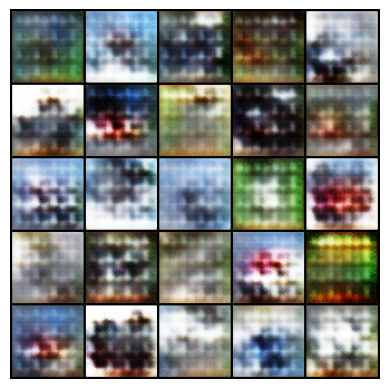

  0%|          | 0/391 [00:00<?, ?it/s]


[Step 1000] Generator Loss: 1.517413 | Discriminator Loss: 0.604639


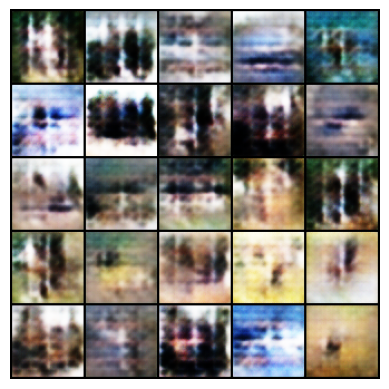

  0%|          | 0/391 [00:00<?, ?it/s]


[Step 1500] Generator Loss: 1.688273 | Discriminator Loss: 0.570167


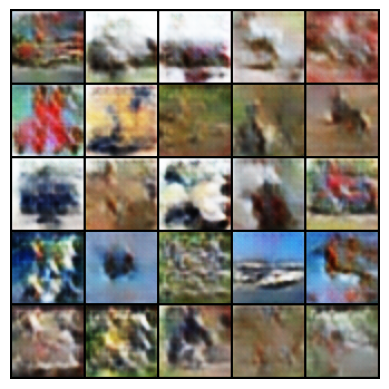

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]


[Step 2000] Generator Loss: 3.059064 | Discriminator Loss: 0.360349


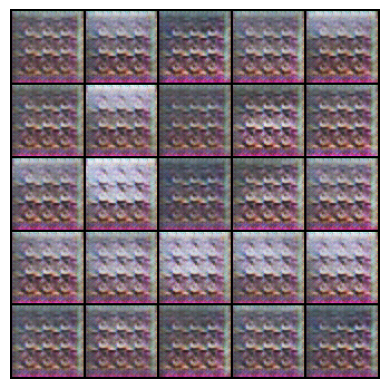

  0%|          | 0/391 [00:00<?, ?it/s]


[Step 2500] Generator Loss: 4.563097 | Discriminator Loss: 0.251723


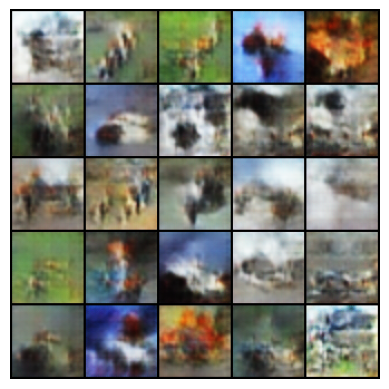

  0%|          | 0/391 [00:00<?, ?it/s]


[Step 3000] Generator Loss: 4.019779 | Discriminator Loss: 0.243695


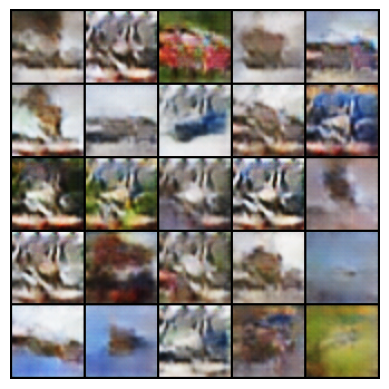

In [ ]:
for epoch in range(n_epochs):
    for real, _ in tqdm(dataloader):
        cur_batch_size = len(real)
        real = real.to(device)
 
        # train Discriminator
        disc_opt.zero_grad()
        disc_loss = get_disc_loss(gen, disc, criterion, real, cur_batch_size, z_dim, device)
        disc_loss.backward()
        disc_opt.step()
        
        # Cumulative D Loss
        total_disc_loss += disc_loss.item()
        
        # Train  Generator (spped up)
        batch_gen_loss = 0
        for _ in range(2):
            gen_opt.zero_grad()
            gen_loss = get_gen_loss(gen, disc, criterion, cur_batch_size, z_dim, device)
            gen_loss.backward()
            gen_opt.step()
            batch_gen_loss += gen_loss.item()                  
 
        # mean_discriminator_loss += disc_loss.item() / display_step
        # mean_generator_loss += gen_loss.item() / display_step
        
        # Cumulative G Loss
        total_gen_loss += (batch_gen_loss / 2)
 
 
        #Display the output
        if cur_step % display_step == 0 and cur_step > 0:
            avg_gen = total_gen_loss / display_step
            avg_disc = total_disc_loss / display_step
            
            # print(f"Step {cur_step}: Generator loss: {mean_generator_loss:.4f}, Discriminator loss: {mean_discriminator_loss:.4f}")
            print(f"\n[Step {cur_step}] Generator Loss: {avg_gen:.6f} | Discriminator Loss: {avg_disc:.6f}")
            
            # fake_noise = get_noise(cur_batch_size, z_dim, device=device)
            # fake = gen(fake_noise)
            # show_tensor_images(fake)
            # show_tensor_images(real)
            # mean_generator_loss = 0
            # mean_discriminator_loss = 0
            
            fake_noise = get_noise(cur_batch_size, z_dim, device=device)
            fake = gen(fake_noise)
            show_tensor_images(fake)
            
            # Reset Cumulator    
            total_gen_loss = 0
            total_disc_loss = 0
 
        cur_step += 1

### Observation:

Decision: Due to the signs of Mode Collapse at Step 19,000, training was terminated early to preserve the best results.

Final Output: The weights from Step 17,500 were selected as the final model due to their superior balance of diversity and clarity.


**Question:** Explain how the labels are different during training the Discriminator and the Generator.

The labels represent different objectives of the two networks in a GAN:

Discriminator Labels: The Discriminator is aim to correctly classify images. Therefore, it uses ground truth labels: 1 (Real) for actual images from the dataset and 0 (Fake) for images produced by the Generator. This helps the model learn to distinguish between real and synthetic data.

Generator Labels: The Generator is aim to fool the Discriminator. When training the Generator, we use inverted labels. Even though the images are fake, the target label is set to 1 (Real). This forces the Generator to update its weights in a way that makes its output look more like authentic data to minimize the loss.

### Save the result

In [ ]:
torch.save(gen.state_dict(), "cifar10_gen_best_step11500.pth")

# save image
from torchvision.utils import save_image
save_image(fake.data, "HW5_generated_image_YunJiungWang.png", normalize=True)

print("image saved")

Welcome to my first Colab